# Módulo C.1 — Explicabilidad (SHAP) e informe

Para entender por qué el modelo real determina la idoneidad de un lugar utilizando SHAP, es fundamental analizar cómo este enfoque ayuda a interpretar las decisiones del modelo. SHAP ( Shapley Additive Explanations), proporciona una forma de desglosar la predicción del modelo en contribuciones individuales de cada característica. Esto permite identificar qué factores son más influyentes en la evaluación de la idoneidad de un sitio específico.

**Requisito:** el B.3 guardó `modelo_teasuitability_real.pkl`.

# 1. Instalar librerías

In [1]:
!pip install shap xgboost lightgbm rasterio -q

# 2. Importaciones

In [2]:
import os                                       # comprobar rutas y archivos
from pathlib import Path                        # manejar rutas
import warnings                                 # silenciar avisos
import joblib                                   # cargar el modelo (.pkl)
import numpy as np                              # cálculo numérico
import pandas as pd                             # tablas de datos
import shap                                     # explicar las predicciones (XAI)
import rasterio                                 # leer los rasters (muestrear Turrialba)
from rasterio.warp import transform as warp_transform  # pH (SoilGrids)
import matplotlib.pyplot as plt                 # gráfico de factores
# clases necesarias para poder cargar el modelo guardado (.pkl):
from lightgbm import LGBMClassifier             # modelo LightGBM
from sklearn.ensemble import (RandomForestClassifier,   # Random Forest
                              StackingClassifier)        # stacking
from sklearn.linear_model import LogisticRegression     # meta-modelo
from sklearn.pipeline import make_pipeline      # encadenar escalado + SVM
from sklearn.preprocessing import StandardScaler # estandarizar
from sklearn.svm import SVC                       # modelo SVM
from xgboost import XGBClassifier                 # XGBoost
warnings.filterwarnings('ignore')                # oculta avisos para salida limpia

# 3. Cardar el modelo, el conjunto de datos y preparamos los datos

Aquí se define todo lo que se necesita: el modelo, el conjunto de datos, las variables X y las rutas de los rasters.

Con ello se evita depender del orden en que se ejecutan las celdas.

In [3]:
# Montar Drive
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

# Rutas del proyecto
CARPETA_BASE = Path('/content/drive/MyDrive/TFM_TeaSuitability')
CARPETA_CLIMA = CARPETA_BASE / 'worldclim'
RUTA_MODELO = CARPETA_BASE / 'modelo_teasuitability_real.pkl'
RUTA_CSV = CARPETA_BASE / 'dataset_master.csv'

# Comprobación de que existe el modelo
if not RUTA_MODELO.exists():
    raise FileNotFoundError('Falta el modelo. Ejecuta primero el B.3.')

# Cargar modelo y dataset
modelo = joblib.load(RUTA_MODELO)               # modelo entrenado (del B.3)
dataset = pd.read_csv(RUTA_CSV)                  # datos reales

# variables predictoras (mismo orden que en el entrenamiento)
# Las 8 variables predictoras (mismo orden que en el entrenamiento del B.3)
columnas = [
    'temperatura_media',        # bio1: temperatura media anual (óptimo del té: 18-25 °C)
    'rango_diurno',             # bio2: diferencia entre la máxima del día y la mínima nocturna
    'precipitacion_anual',      # bio12: lluvia total anual (óptimo 1500-3000 mm)
    'estacionalidad_precip',    # bio15: variación de la lluvia entre estaciones
    'precip_trimestre_seco',    # bio17: lluvia en la estación seca (estrés hídrico)
    'elevacion',                # altitud del terreno (el té se cultiva hasta ~2200 m)
    'ph_suelo',                 # pH del suelo (SoilGrids); el té prefiere ácido, 4.5-5.5
]
X = dataset[columnas]                           # fondo de referencia para SHAP

# rutas de los rasters (del A.1) para muestrear cualquier punto
CAPAS = {
    'temperatura_media':      CARPETA_CLIMA / 'wc2.1_5m_bio_1.tif',   # bio1
    'rango_diurno':           CARPETA_CLIMA / 'wc2.1_5m_bio_2.tif',   # bio2
    'precipitacion_anual':    CARPETA_CLIMA / 'wc2.1_5m_bio_12.tif',  # bio12
    'estacionalidad_precip':  CARPETA_CLIMA / 'wc2.1_5m_bio_15.tif',  # bio15
    'precip_trimestre_seco':  CARPETA_CLIMA / 'wc2.1_5m_bio_17.tif',  # bio17
    'elevacion':              CARPETA_CLIMA / 'wc2.1_5m_elev.tif',    # elevación
}

print('Modelo y datos cargados. X:', X.shape)

Mounted at /content/drive
Modelo y datos cargados. X: (1333, 7)


# 4. Funciones (explicabilidad, muestreo, bandas e informe)

In [4]:
def crear_explicador(modelo, X_fondo, n_fondo=10):
    """
    Crea un explicador SHAP para la probabilidad de idoneidad del modelo.

    Parameters
    ----------
    modelo : estimator
        Modelo entrenado con método predict_proba.
    X_fondo : pandas.DataFrame
        Datos de referencia (fondo) para SHAP.
    n_fondo : int, optional
        Nº de puntos resumen del fondo (kmeans). Por defecto 10.

    Returns
    -------
    shap.KernelExplainer
        El explicador listo para usar.
    """
    fondo = shap.kmeans(X_fondo, n_fondo)        # resume el fondo para ir rápido
    return shap.KernelExplainer(lambda z: modelo.predict_proba(z)[:, 1], fondo)


def muestrear_punto(lon, lat, capas, respaldo):
    """
    Extrae las variables reales de un punto desde los rasters.

    Si algún raster no está disponible, usa los valores de respaldo (por
    ejemplo, el perfil medio de las presencias), para no interrumpir el flujo.

    Parameters
    ----------
    lon, lat : float
        Coordenadas (longitud, latitud).
    capas : dict of {str: pathlib.Path}
        Diccionario {nombre_variable: ruta_del_raster}.
    respaldo : dict of {str: float}
        Valores de reserva si faltan los rasters.

    Returns
    -------
    pandas.DataFrame
        Una fila con las variables del punto.
    """
    valores = {}
    for nombre, ruta in capas.items():
        if Path(ruta).exists():                  # si el raster está, se muestrea
            with rasterio.open(ruta) as raster:
                valores[nombre] = float(next(raster.sample([(lon, lat)]))[0])
        else:                                    # si no, se usa el respaldo
            valores[nombre] = respaldo[nombre]
    return pd.DataFrame([valores])[list(capas.keys())]


def probabilidad_a_banda(probabilidad):
    """
    Traduce una probabilidad (0-1) a banda de idoneidad.

    Returns
    -------
    str
        'No apta', 'Baja', 'Media' o 'Alta'.
    """
    if probabilidad < 0.25:
        return 'No apta'
    if probabilidad < 0.50:
        return 'Baja'
    if probabilidad < 0.75:
        return 'Media'
    return 'Alta'


def generar_informe(punto, probabilidad, banda, contribuciones):
    """
    Redacta un informe en lenguaje natural explicando la idoneidad.

    Parameters
    ----------
    punto : pandas.DataFrame
        Fila con las condiciones del lugar.
    probabilidad : float
        Probabilidad de idoneidad (0-1).
    banda : str
        Banda de idoneidad.
    contribuciones : dict of {str: float}
        Contribuciones SHAP de cada variable.

    Returns
    -------
    str
        El informe completo como texto.
    """
    ordenadas = sorted(contribuciones.items(), key=lambda x: abs(x[1]), reverse=True)
    lineas = [
        'INFORME DE IDONEIDAD PARA CULTIVO DE TÉ',
        '=' * 45,
        f'Resultado: idoneidad {banda.upper()} '
        f'(probabilidad estimada: {probabilidad:.1%}).',
        '',
        'Factores que más influyen:',
    ]
    for variable, valor in ordenadas:
        efecto = 'FAVORECE la idoneidad' if valor >= 0 else 'REDUCE la idoneidad'
        lineas.append(f'  - {variable}: {efecto} (peso {abs(valor):.3f}).')
    lineas.append('')
    lineas.append(
        f"En resumen, el factor más determinante es '{ordenadas[0][0]}'. "
        f'El sistema clasifica este lugar como de idoneidad {banda.lower()}.')
    return '\n'.join(lineas)


# URL del mapa de pH de SoilGrids (media, 0-5 cm), lectura remota
URL_PH = ('/vsicurl/https://files.isric.org/soilgrids/latest/data/'
          'phh2o/phh2o_0-5cm_mean.vrt')


def muestrear_ph_soilgrids(lon, lat, url=URL_PH):
    """Obtiene el pH del suelo (SoilGrids) en un punto (lon, lat).

    Transforma la coordenada a la proyección Homolosine de SoilGrids y
    muestrea el pH (viene x10, se divide entre 10). Devuelve NaN si no hay dato.
    """
    with rasterio.open(url) as src:
        xs, ys = warp_transform('EPSG:4326', src.crs, [lon], [lat])
        v = float(next(src.sample(list(zip(xs, ys))))[0])
    return np.nan if v == src.nodata else v / 10.0

# 5. Crear el explicador SHAP

In [5]:
explicador = crear_explicador(modelo, X, n_fondo=10)
print('Explicador SHAP creado.')

Explicador SHAP creado.


# 6. Evaluar y explicar Turrialba (con sus datos reales)

In [6]:
# perfil medio de las presencias, como respaldo si faltara algún raster
respaldo = X[dataset['clase'] == 1].mean().to_dict()

# Turrialba, Cartago (Costa Rica): muestreamos sus condiciones reales
turrialba = muestrear_punto(-83.6855, 9.9044, CAPAS, respaldo)

# pH del suelo de Turrialba (SoilGrids); si falla o sale NaN, usamos el respaldo
try:
    ph_turrialba = muestrear_ph_soilgrids(-83.6855, 9.9044)
except Exception:
    ph_turrialba = np.nan
if pd.isna(ph_turrialba):
    ph_turrialba = respaldo['ph_suelo']
turrialba['ph_suelo'] = ph_turrialba
turrialba = turrialba[columnas]   # 7 columnas, mismo orden que el modelo
print('Condiciones de Turrialba:')
print(turrialba.round(1).to_dict('records')[0])

# predicción y explicación
prob = modelo.predict_proba(turrialba)[0, 1]
banda = probabilidad_a_banda(prob)
valores_shap = explicador.shap_values(turrialba, nsamples=100)
contribuciones = dict(zip(columnas, valores_shap[0]))
print('\nTurrialba ->', f'{prob:.1%}', '| Banda:', banda)

Condiciones de Turrialba:
{'temperatura_media': 21.6, 'rango_diurno': 9.8, 'precipitacion_anual': 2955.0, 'estacionalidad_precip': 33.7, 'precip_trimestre_seco': 367.0, 'elevacion': 897.0, 'ph_suelo': 5.3}


  0%|          | 0/1 [00:00<?, ?it/s]


Turrialba -> 54.4% | Banda: Media


# 7. Gráfico de factores (por qué este resultado)

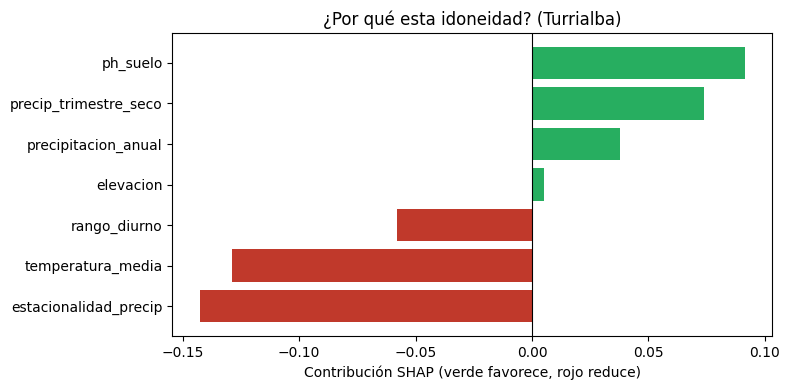

In [7]:
orden = sorted(contribuciones.items(), key=lambda x: x[1])
nombres = [n for n, _ in orden]
valores = [v for _, v in orden]
colores = ['#c0392b' if v < 0 else '#27ae60' for v in valores]  # rojo reduce, verde favorece

plt.figure(figsize=(8, 4))
plt.barh(nombres, valores, color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Contribución SHAP (verde favorece, rojo reduce)')
plt.title('¿Por qué esta idoneidad? (Turrialba)')
plt.tight_layout(); plt.show()

# 8. Informe en lenguaje natural

In [8]:
informe = generar_informe(turrialba, prob, banda, contribuciones)
print(informe)

INFORME DE IDONEIDAD PARA CULTIVO DE TÉ
Resultado: idoneidad MEDIA (probabilidad estimada: 54.4%).

Factores que más influyen:
  - estacionalidad_precip: REDUCE la idoneidad (peso 0.143).
  - temperatura_media: REDUCE la idoneidad (peso 0.129).
  - ph_suelo: FAVORECE la idoneidad (peso 0.092).
  - precip_trimestre_seco: FAVORECE la idoneidad (peso 0.074).
  - rango_diurno: REDUCE la idoneidad (peso 0.058).
  - precipitacion_anual: FAVORECE la idoneidad (peso 0.038).
  - elevacion: FAVORECE la idoneidad (peso 0.005).

En resumen, el factor más determinante es 'estacionalidad_precip'. El sistema clasifica este lugar como de idoneidad media.
